# 🔬 Notebook 4: Swin Transformer vs ViT — RBC Classification

So sánh **Swin Transformer** (implement từ đầu, pure PyTorch) với **ViT** từ Notebook 02.

| | ViT (Notebook 02) | Swin Transformer (Notebook 04) |
|---|---|---|
| Patch | 8×8, fixed | 4×4, shifted windows |
| Attention | Global | Local window → hierarchical |
| Params | ~200K | ~400K |
| Phù hợp | Ảnh nhỏ | Ảnh nhỏ có patterns cục bộ |

**Cùng data, cùng training setup → so sánh công bằng.**

In [13]:
import os, random, time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
from tqdm import tqdm
from collections import Counter
from sklearn.metrics import classification_report, confusion_matrix

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")
torch.manual_seed(42)
random.seed(42)
np.random.seed(42)

Device: cpu


In [14]:
# ── Config (GIỐNG hệt Notebook 02 để so sánh công bằng) ──────────────────────
DATASET_BASE = r"c:\Users\DELL\Desktop\Vinh Hoang\Master Program\Học sâu\Project\Dataset"
# from google.colab import drive; drive.mount('/content/drive')
# DATASET_BASE = "/content/drive/MyDrive/Project/Dataset"

CLS_DIR           = os.path.join(DATASET_BASE, "Elsafty_RBCs_for_Classification", "Cropped images")
IMG_SIZE          = 80
BATCH_SIZE        = 64
EPOCHS            = 50
LR = 5e-5 
SAMPLES_PER_CLASS = 1500

RESULTS_DIR = os.path.join(os.path.dirname(DATASET_BASE), "results", "classification")
os.makedirs(RESULTS_DIR, exist_ok=True)
print("Config OK")

Config OK


In [15]:
# ── Dataset Loading & Stratified Split ───────────────────────────────────────────────────────────────────
import zipfile, shutil
from pathlib import Path
import random
from collections import Counter
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as transforms
from PIL import Image

cls_dir_path = Path(CLS_DIR)

# 1. Tự động giải nén tất cả các file zip nếu có
for z in cls_dir_path.glob("*.zip"):
    print(f"Bung file nén: {z.name} ...")
    with zipfile.ZipFile(z, 'r') as zf:
        zf.extractall(cls_dir_path)

# 2. Dọn dẹp: Xóa các thư mục rỗng hoặc không chứa ảnh
for d in list(cls_dir_path.iterdir()):
    if d.is_dir() and not d.name.startswith('.'):
        has_png = any(d.rglob("*.png"))
        if not has_png:
            print(f"🗑️ Đang xóa thư mục rỗng/thừa: {d.name}")
            shutil.rmtree(d)

# 3. Lấy danh sách class
CLASSES = sorted([d.name for d in cls_dir_path.iterdir() if d.is_dir() and any(d.glob("*.png"))])
print(f"Classes ({len(CLASSES)}): {CLASSES}")
CLASS2IDX = {c: i for i, c in enumerate(CLASSES)}

class RBCClsDataset(Dataset):
    def __init__(self, samples, augment=False):
        self.samples = samples
        base = [transforms.Resize((IMG_SIZE, IMG_SIZE)), transforms.ToTensor(),
                transforms.Normalize([0.5]*3, [0.5]*3)]
        aug  = [transforms.RandomHorizontalFlip(), transforms.RandomVerticalFlip(),
                transforms.RandomRotation(15)]
        self.tf = transforms.Compose((aug if augment else []) + base)

    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        path, label = self.samples[idx]
        return self.tf(Image.open(path).convert("RGB")), label

def load_samples(cls_dir, spc, classes):
    samples = []
    for cls in classes:
        folder = Path(cls_dir) / cls
        files  = sorted(folder.glob("*.png"))
        if len(files) == 0: continue
        chosen = random.sample(list(files), min(spc, len(files)))
        for f in chosen:
            samples.append((str(f), CLASS2IDX[cls]))
    random.shuffle(samples)
    return samples

# --- EXECUTE LOADING ---
all_samples = load_samples(CLS_DIR, SAMPLES_PER_CLASS, CLASSES)
print(f"Total samples before split: {len(all_samples)}")

# --- START FIX: STRATIFIED SPLIT ---
all_paths = [s[0] for s in all_samples]
all_labels = [s[1] for s in all_samples]

train_val_paths, test_paths, train_val_labels, test_labels = train_test_split(
    all_paths, all_labels, test_size=0.15, random_state=42, stratify=all_labels
)

train_paths, val_paths, train_labels, val_labels = train_test_split(
    train_val_paths, train_val_labels, test_size=0.1765, random_state=42, stratify=train_val_labels
)

train_s = list(zip(train_paths, train_labels))
val_s = list(zip(val_paths, val_labels))
test_s = list(zip(test_paths, test_labels))

train_ds = RBCClsDataset(train_s, augment=True)
val_ds   = RBCClsDataset(val_s)
test_ds  = RBCClsDataset(test_s)

class_counts = Counter(train_labels)
class_weights = {cls: 1.0 / count for cls, count in class_counts.items()}
sample_weights = [class_weights[label] for label in train_labels]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

train_dl = DataLoader(train_ds, BATCH_SIZE, sampler=sampler, num_workers=0, pin_memory=(DEVICE=="cuda"))
val_dl   = DataLoader(val_ds,   BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=(DEVICE=="cuda"))
test_dl  = DataLoader(test_ds,  BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=(DEVICE=="cuda"))
print(f"Train/Val/Test Datasets: {len(train_s)}/{len(val_s)}/{len(test_s)}")


Bung file nén: CROPPED - Class 1 - Rounded RBCs.zip ...
Bung file nén: CROPPED - Class 2 - Ovalocytes.zip ...
Bung file nén: CROPPED - Class 3 - Fragmented RBCs.zip ...
Bung file nén: CROPPED - Class 4 - Two Overlapping RBCs.zip ...
Bung file nén: CROPPED - Class 5 - Three Overlapping RBCs.zip ...
Bung file nén: CROPPED - Class 6 - Burr Cells.zip ...
Bung file nén: CROPPED - Class 7 - Teardrops.zip ...
Bung file nén: CROPPED - Class 8 - Angled Cells.zip ...
Bung file nén: CROPPED - Class 9 - Borderline Ovalocytes.zip ...
Classes (9): ['CROPPED - Class 1 - Rounded RBCs', 'CROPPED - Class 2 - Ovalocytes', 'CROPPED - Class 3 - Fragmented RBCs', 'CROPPED - Class 4 - Two Overlapping RBCs', 'CROPPED - Class 5 - Three Overlapping RBCs', 'CROPPED - Class 6 - Burr Cells', 'CROPPED - Class 7 - Teardrops', 'CROPPED - Class 8 - Angled Cells', 'CROPPED - Class 9 - Borderline Ovalocytes']
Total samples before split: 13500
Train/Val/Test Datasets: 9449/2026/2025


## 🏗 Swin Transformer Architecture

Swin Transformer khác ViT ở điểm chính:
- **Window-based attention**: Thay vì attend toàn bộ ảnh như ViT, Swin chia ảnh thành các cửa sổ nhỏ (window) và chỉ attend trong từng cửa sổ → **O(n) thay vì O(n²)**
- **Shifted windows**: Các layer xen kẽ giữa window thường và shifted window để trao đổi thông tin giữa các cửa sổ
- **Hierarchical**: Patch merging giảm resolution dần, giống CNN

In [16]:
# ── Swin Transformer (Pure PyTorch) ──────────────────────────────────────────

def window_partition(x, window_size):
    """Chia feature map thành các windows.
    x: (B, H, W, C) → (num_windows*B, window_size, window_size, C)
    """
    B, H, W, C = x.shape
    x = x.view(B, H // window_size, window_size, W // window_size, window_size, C)
    windows = x.permute(0, 1, 3, 2, 4, 5).contiguous().view(-1, window_size, window_size, C)
    return windows

def window_reverse(windows, window_size, H, W):
    """Ghép windows lại thành feature map.
    windows: (num_windows*B, window_size, window_size, C) → (B, H, W, C)
    """
    B = int(windows.shape[0] / (H * W / window_size / window_size))
    x = windows.view(B, H // window_size, W // window_size, window_size, window_size, -1)
    x = x.permute(0, 1, 3, 2, 4, 5).contiguous().view(B, H, W, -1)
    return x


class WindowAttention(nn.Module):
    """Window-based Multi-head Self-Attention với relative position bias."""
    def __init__(self, dim, window_size, num_heads, qkv_bias=True, dropout=0.0):
        super().__init__()
        self.dim        = dim
        self.window_size = window_size  # Wh, Ww
        self.num_heads  = num_heads
        self.scale      = (dim // num_heads) ** -0.5

        # Relative position bias table
        self.relative_position_bias_table = nn.Parameter(
            torch.zeros((2*window_size-1) * (2*window_size-1), num_heads))
        nn.init.trunc_normal_(self.relative_position_bias_table, std=0.02)

        # Precompute relative position index
        coords_h = torch.arange(window_size)
        coords_w = torch.arange(window_size)
        coords   = torch.stack(torch.meshgrid([coords_h, coords_w]))  # 2, Wh, Ww
        coords_flatten = torch.flatten(coords, 1)  # 2, Wh*Ww
        relative_coords = coords_flatten[:, :, None] - coords_flatten[:, None, :]  # 2, N, N
        relative_coords = relative_coords.permute(1, 2, 0).contiguous()            # N, N, 2
        relative_coords[:, :, 0] += window_size - 1
        relative_coords[:, :, 1] += window_size - 1
        relative_coords[:, :, 0] *= 2 * window_size - 1
        relative_position_index = relative_coords.sum(-1)  # N, N
        self.register_buffer("relative_position_index", relative_position_index)

        self.qkv     = nn.Linear(dim, dim * 3, bias=qkv_bias)
        self.proj    = nn.Linear(dim, dim)
        self.attn_drop = nn.Dropout(dropout)
        self.proj_drop = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        B_, N, C = x.shape
        qkv = self.qkv(x).reshape(B_, N, 3, self.num_heads, C // self.num_heads).permute(2, 0, 3, 1, 4)
        q, k, v = qkv.unbind(0)

        q = q * self.scale
        attn = q @ k.transpose(-2, -1)

        # Relative position bias
        rel_pos_bias = self.relative_position_bias_table[
            self.relative_position_index.view(-1)].view(
            self.window_size**2, self.window_size**2, -1)
        rel_pos_bias = rel_pos_bias.permute(2, 0, 1).contiguous().unsqueeze(0)
        attn = attn + rel_pos_bias

        if mask is not None:
            nW = mask.shape[0]
            attn = attn.view(B_ // nW, nW, self.num_heads, N, N) + mask.unsqueeze(1).unsqueeze(0)
            attn = attn.view(-1, self.num_heads, N, N)

        attn = F.softmax(attn, dim=-1)
        attn = self.attn_drop(attn)

        x = (attn @ v).transpose(1, 2).reshape(B_, N, C)
        x = self.proj_drop(self.proj(x))
        return x


class SwinBlock(nn.Module):
    """Một Swin Transformer Block. shift=True → Shifted Window Attention."""
    def __init__(self, dim, num_heads, window_size=5, shift=False,
                 mlp_ratio=4.0, dropout=0.1, input_resolution=None):
        super().__init__()
        self.dim = dim
        self.window_size = window_size
        self.shift_size  = window_size // 2 if shift else 0
        self.input_resolution = input_resolution

        self.norm1 = nn.LayerNorm(dim)
        self.attn  = WindowAttention(dim, window_size, num_heads, dropout=dropout)
        self.norm2 = nn.LayerNorm(dim)
        mlp_hidden = int(dim * mlp_ratio)
        self.mlp   = nn.Sequential(
            nn.Linear(dim, mlp_hidden), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(mlp_hidden, dim), nn.Dropout(dropout))

        # Compute attention mask for shifted windows
        if self.shift_size > 0 and input_resolution is not None:
            H, W = input_resolution
            img_mask = torch.zeros(1, H, W, 1)
            h_slices = (slice(0, -window_size), slice(-window_size, -self.shift_size), slice(-self.shift_size, None))
            w_slices = (slice(0, -window_size), slice(-window_size, -self.shift_size), slice(-self.shift_size, None))
            cnt = 0
            for h in h_slices:
                for w in w_slices:
                    img_mask[:, h, w, :] = cnt
                    cnt += 1
            mask_windows = window_partition(img_mask, window_size).view(-1, window_size*window_size)
            attn_mask = mask_windows.unsqueeze(1) - mask_windows.unsqueeze(2)
            attn_mask = attn_mask.masked_fill(attn_mask != 0, -100.0).masked_fill(attn_mask == 0, 0.0)
        else:
            attn_mask = None
        self.register_buffer("attn_mask", attn_mask)

    def forward(self, x):
        # x: (B, L, C) where L = H*W
        H, W = self.input_resolution
        B, L, C = x.shape
        shortcut = x
        x = self.norm1(x).view(B, H, W, C)

        # Cyclic shift
        if self.shift_size > 0:
            x = torch.roll(x, shifts=(-self.shift_size, -self.shift_size), dims=(1, 2))

        # Window partition
        x_windows = window_partition(x, self.window_size).view(-1, self.window_size**2, C)

        # Attention
        x_windows = self.attn(x_windows, mask=self.attn_mask)

        # Reverse
        x = window_reverse(x_windows.view(-1, self.window_size, self.window_size, C),
                           self.window_size, H, W)

        # Reverse cyclic shift
        if self.shift_size > 0:
            x = torch.roll(x, shifts=(self.shift_size, self.shift_size), dims=(1, 2))

        x = x.view(B, H*W, C)
        x = shortcut + x
        x = x + self.mlp(self.norm2(x))
        return x


class PatchMerging(nn.Module):
    """Giảm resolution 2x, tăng channel 2x (như pooling trong CNN)."""
    def __init__(self, dim, input_resolution):
        super().__init__()
        self.input_resolution = input_resolution
        self.norm = nn.LayerNorm(4 * dim)
        self.reduction = nn.Linear(4 * dim, 2 * dim, bias=False)

    def forward(self, x):
        H, W = self.input_resolution
        B, L, C = x.shape
        x = x.view(B, H, W, C)
        x0 = x[:, 0::2, 0::2, :]
        x1 = x[:, 1::2, 0::2, :]
        x2 = x[:, 0::2, 1::2, :]
        x3 = x[:, 1::2, 1::2, :]
        x  = torch.cat([x0, x1, x2, x3], dim=-1).view(B, -1, 4*C)
        return self.reduction(self.norm(x))


class SwinClassifier(nn.Module):
    """
    Swin Transformer cho ảnh 80x80, 9 classes.
    
    Stage 0: patch_size=4 → 20x20 patches, dim=64
    Stage 1: 2 SwinBlocks (W-MSA + SW-MSA)
    PatchMerging → 10x10, dim=128
    Stage 2: 2 SwinBlocks
    PatchMerging → 5x5, dim=256
    Stage 3: 2 SwinBlocks
    Global Average Pool → classify
    """
    def __init__(self, img_size=80, patch_size=4, in_ch=3,
                 n_classes=9, embed_dim=64,
                 depths=(2, 2, 2), num_heads=(4, 8, 16),
                 window_size=5, mlp_ratio=4.0, dropout=0.1):
        super().__init__()
        self.num_layers = len(depths)

        # Patch Embedding (giống ViT nhưng patch nhỏ hơn)
        self.patch_embed = nn.Conv2d(in_ch, embed_dim, kernel_size=patch_size, stride=patch_size)
        self.patch_norm  = nn.LayerNorm(embed_dim)
        self.pos_drop    = nn.Dropout(dropout)

        patches_resolution = img_size // patch_size  # 80//4 = 20

        # Build stages
        self.layers = nn.ModuleList()
        dim = embed_dim
        res = patches_resolution

        for i_layer, depth in enumerate(depths):
            stage_blocks = nn.ModuleList([
                SwinBlock(
                    dim=dim,
                    num_heads=num_heads[i_layer],
                    window_size=window_size,
                    shift=(j % 2 == 1),  # xen kẽ W-MSA và SW-MSA
                    mlp_ratio=mlp_ratio,
                    dropout=dropout,
                    input_resolution=(res, res)
                ) for j in range(depth)
            ])
            downsample = PatchMerging(dim, (res, res)) if i_layer < len(depths) - 1 else None
            self.layers.append(nn.ModuleDict({
                'blocks': stage_blocks,
                'downsample': downsample if downsample else nn.Identity()
            }))
            if i_layer < len(depths) - 1:
                dim *= 2
                res //= 2

        self.final_dim  = dim
        self.norm       = nn.LayerNorm(dim)
        self.avgpool    = nn.AdaptiveAvgPool1d(1)
        self.head       = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(dim, n_classes)
        )

    def forward(self, x):
        # Patch embedding
        x = self.patch_embed(x)            # B, C, H/p, W/p
        B, C, H, W = x.shape
        x = x.flatten(2).transpose(1, 2)   # B, L, C
        x = self.pos_drop(self.patch_norm(x))

        # Stages
        for layer in self.layers:
            for blk in layer['blocks']:
                x = blk(x)
            ds = layer['downsample']
            if not isinstance(ds, nn.Identity):
                x = ds(x)

        # Classification
        x = self.norm(x)            # B, L, C
        x = self.avgpool(x.transpose(1, 2)).squeeze(-1)  # B, C
        return self.head(x)


model_swin = SwinClassifier(n_classes=len(CLASSES)).to(DEVICE)
n_params = sum(p.numel() for p in model_swin.parameters())
print(f"Swin Transformer params: {n_params:,}")

# Kiểm tra forward pass
x_test = torch.randn(4, 3, 80, 80).to(DEVICE)
with torch.no_grad():
    out = model_swin(x_test)
print(f"Output shape: {out.shape}  ← Expected (4, 9)")

Swin Transformer params: 2,252,033
Output shape: torch.Size([4, 9])  ← Expected (4, 9)


## 🎯 Training Loop

In [17]:
def train_model(model, train_dl, val_dl, epochs, lr, save_path, model_name):
    optimizer  = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler  = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion  = nn.CrossEntropyLoss(label_smoothing=0.1)

    best_acc, patience, no_improve = 0.0, 20, 0
    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
    t0 = time.time()

    for epoch in range(1, epochs + 1):
        # Train
        model.train()
        total_loss = 0
        for xb, yb in tqdm(train_dl, desc=f"[{model_name}] Epoch {epoch}/{epochs}", leave=False):
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total_loss += loss.item()
        scheduler.step()

        # Validate
        model.eval()
        val_loss, correct, total = 0, 0, 0
        with torch.no_grad():
            for xb, yb in val_dl:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                out = model(xb)
                val_loss += criterion(out, yb).item()
                correct  += (out.argmax(1) == yb).sum().item()
                total    += yb.size(0)

        acc = correct / total
        history['train_loss'].append(total_loss / len(train_dl))
        history['val_loss'].append(val_loss   / len(val_dl))
        history['val_acc'].append(acc)

        print(f"[{model_name}] Epoch {epoch:02d} | "
              f"Train Loss: {history['train_loss'][-1]:.4f} | "
              f"Val Loss: {history['val_loss'][-1]:.4f} | "
              f"Val Acc: {acc:.4f}")

        if acc > best_acc:
            best_acc   = acc
            no_improve = 0
            torch.save(model.state_dict(), save_path)
            print(f"  ✅ Best saved: {acc:.4f}")
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"  ⏹ Early stopping at epoch {epoch}")
                break

    elapsed = time.time() - t0
    print(f"\n✅ {model_name} done | Best Val Acc: {best_acc:.4f} | Time: {elapsed/60:.1f} min")
    return history, best_acc

In [18]:
# ── Train Swin Transformer ────────────────────────────────────────────────────
SWIN_PATH = os.path.join(RESULTS_DIR, "Swin_Cls_best.pt")

history_swin, best_acc_swin = train_model(
    model_swin, train_dl, val_dl,
    epochs=EPOCHS, lr=LR,
    save_path=SWIN_PATH,
    model_name="SwinTransformer"
)

[SwinTransformer] Epoch 01 | Train Loss: 2.1761 | Val Loss: 2.0548 | Val Acc: 0.2354
  ✅ Best saved: 0.2354


[SwinTransformer] Epoch 02 | Train Loss: 2.0584 | Val Loss: 1.9731 | Val Acc: 0.2897
  ✅ Best saved: 0.2897


[SwinTransformer] Epoch 03 | Train Loss: 1.9332 | Val Loss: 1.9495 | Val Acc: 0.3001
  ✅ Best saved: 0.3001


[SwinTransformer] Epoch 04 | Train Loss: 1.8384 | Val Loss: 1.7998 | Val Acc: 0.3885
  ✅ Best saved: 0.3885


[SwinTransformer] Epoch 05 | Train Loss: 1.7176 | Val Loss: 1.7403 | Val Acc: 0.3954
  ✅ Best saved: 0.3954


...

[SwinTransformer] Epoch 46 | Train Loss: 1.1080 | Val Loss: 1.2788 | Val Acc: 0.6264


[SwinTransformer] Epoch 47 | Train Loss: 1.1030 | Val Loss: 1.2757 | Val Acc: 0.6303


[SwinTransformer] Epoch 48 | Train Loss: 1.0927 | Val Loss: 1.2719 | Val Acc: 0.6298


[SwinTransformer] Epoch 49 | Train Loss: 1.1060 | Val Loss: 1.2711 | Val Acc: 0.6288


[SwinTransformer] Epoch 50 | Train Loss: 1.1188 | Val Loss: 1.2710 | Val Acc: 0.6293

✅ SwinTransformer done | Best Val Acc: 0.6333 | Time: 235.5 min


## 📊 Test Evaluation & So sánh với ViT

In [19]:
def evaluate_model(model, test_dl, weight_path, model_name):
    model.load_state_dict(torch.load(weight_path, map_location=DEVICE))
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for xb, yb in test_dl:
            xb = xb.to(DEVICE)
            preds = model(xb).argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(yb.numpy())
    acc = sum(p==l for p,l in zip(all_preds, all_labels)) / len(all_labels)
    print(f"\n{'='*50}")
    print(f"📊 {model_name} — Test Accuracy: {acc:.4f}")
    print(f"{'='*50}")
    short_classes = [c.replace('CROPPED - Class ', 'C').split(' - ')[0] + ' ' +
                     c.split(' - ')[-1][:8] for c in CLASSES]
    print(classification_report(all_labels, all_preds, target_names=short_classes, digits=3))
    return acc, all_preds, all_labels

# Evaluate Swin
swin_acc, swin_preds, swin_labels = evaluate_model(
    model_swin, test_dl, SWIN_PATH, "Swin Transformer")


📊 Swin Transformer — Test Accuracy: 0.6410
              precision    recall  f1-score   support

 C1 Rounded       0.634     0.907     0.746       225
 C2 Ovalocyt      0.518     0.564     0.540       225
 C3 Fragment      0.925     0.827     0.873       225
 C4 Two Over      0.646     0.707     0.675       225
 C5 Three Ov      0.780     0.693     0.734       225
 C6 Burr Cel      0.538     0.440     0.484       225
 C7 Teardrop      0.596     0.747     0.663       225
 C8 Angled C      0.594     0.409     0.484       225
 C9 Borderli      0.563     0.476     0.516       225

    accuracy                          0.641      2025
   macro avg      0.644     0.641     0.635      2025
weighted avg      0.644     0.641     0.635      2025



In [20]:
# Load ViT từ Notebook 02 để so sánh
# ──────────────────────────────────────────────────────────────────────────────
class TransBlock(nn.Module):
    def __init__(self, dim=128, heads=4, mlp_ratio=3, drop=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn  = nn.MultiheadAttention(dim, heads, dropout=drop, batch_first=True)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp   = nn.Sequential(
            nn.Linear(dim, dim*mlp_ratio), nn.GELU(), nn.Dropout(drop),
            nn.Linear(dim*mlp_ratio, dim), nn.Dropout(drop))
    def forward(self, x):
        n = self.norm1(x); x = x + self.attn(n,n,n)[0]
        return x + self.mlp(self.norm2(x))

class ViTClassifier(nn.Module):
    def __init__(self, img_size=80, patch_size=8, in_ch=3, n_classes=9,
                 embed_dim=128, depth=4, heads=4):
        super().__init__()
        n_patches = (img_size // patch_size) ** 2
        self.patch_proj = nn.Conv2d(in_ch, embed_dim, patch_size, patch_size)
        self.cls_token  = nn.Parameter(torch.randn(1, 1, embed_dim) * 0.02)
        self.pos_embed  = nn.Parameter(torch.randn(1, n_patches + 1, embed_dim) * 0.02)
        self.blocks     = nn.Sequential(*[TransBlock(embed_dim, heads) for _ in range(depth)])
        self.norm       = nn.LayerNorm(embed_dim)
        self.head       = nn.Linear(embed_dim, n_classes)
    def forward(self, x):
        B = x.shape[0]
        x = self.patch_proj(x).flatten(2).transpose(1, 2)
        cls = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls, x], dim=1) + self.pos_embed
        x = self.norm(self.blocks(x))
        return self.head(x[:, 0])

VIT_PATH = os.path.join(RESULTS_DIR, "ViT_Cls_best.pt")
model_vit = ViTClassifier(n_classes=len(CLASSES)).to(DEVICE)
vit_n_params = sum(p.numel() for p in model_vit.parameters())

if os.path.exists(VIT_PATH):
    vit_acc, vit_preds, vit_labels = evaluate_model(
        model_vit, test_dl, VIT_PATH, "ViT (Notebook 02)")
else:
    print("⚠ Chưa có ViT_Cls_best.pt. Chạy Notebook 02 trước để có file này.")
    vit_acc = None


📊 ViT (Notebook 02) — Test Accuracy: 0.7659
              precision    recall  f1-score   support

 C1 Rounded       0.845     0.898     0.871       225
 C2 Ovalocyt      0.648     0.751     0.695       225
 C3 Fragment      0.965     0.987     0.976       225
 C4 Two Over      0.852     0.791     0.820       225
 C5 Three Ov      0.822     0.902     0.860       225
 C6 Burr Cel      0.599     0.471     0.527       225
 C7 Teardrop      0.780     0.836     0.807       225
 C8 Angled C      0.663     0.551     0.602       225
 C9 Borderli      0.679     0.707     0.693       225

    accuracy                          0.766      2025
   macro avg      0.761     0.766     0.761      2025
weighted avg      0.761     0.766     0.761      2025




📊 BẢNG SO SÁNH: ViT vs Swin Transformer
Model                    Params   Test Acc
------------------------------------------
ViT (NB02)              700,681     0.7659
Swin Transf.          2,252,033     0.6410


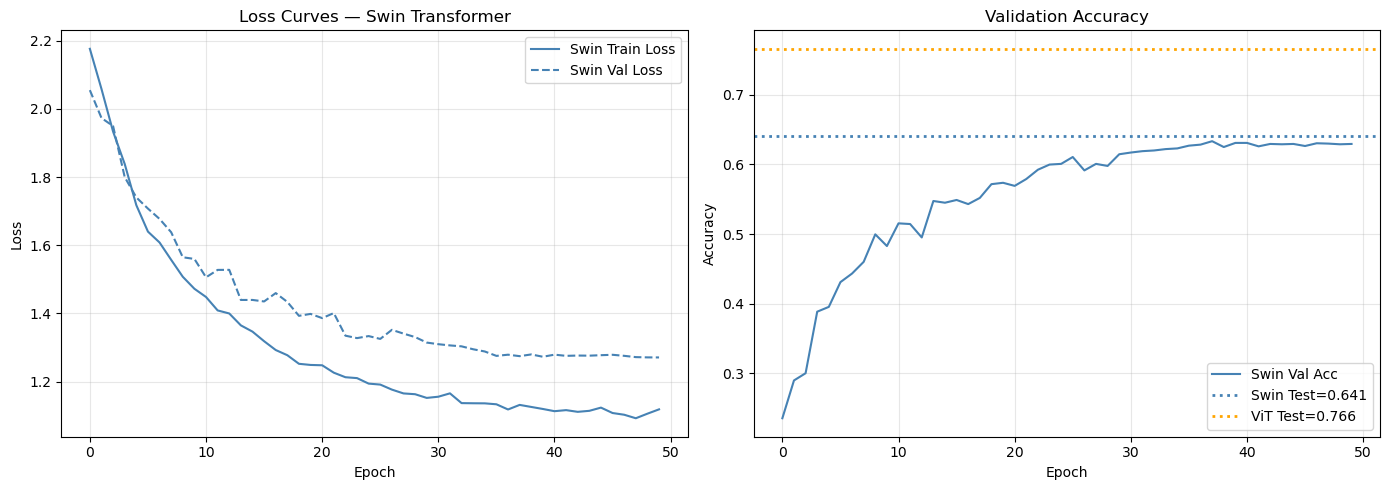

In [21]:
# ── So sánh tổng hợp ──────────────────────────────────────────────────────────
print("\n" + "="*60)
print("📊 BẢNG SO SÁNH: ViT vs Swin Transformer")
print("="*60)
print(f"{'Model':<20} {'Params':>10} {'Test Acc':>10}")
print("-"*42)
print(f"{'ViT (NB02)':<20} {vit_n_params:>10,} {str(f'{vit_acc:.4f}') if vit_acc else 'N/A':>10}")
print(f"{'Swin Transf.':<20} {n_params:>10,} {swin_acc:>10.4f}")
print("="*60)

# Learning curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_swin['train_loss'], label='Swin Train Loss', color='steelblue')
axes[0].plot(history_swin['val_loss'],   label='Swin Val Loss',   color='steelblue', linestyle='--')
axes[0].set_title('Loss Curves — Swin Transformer')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history_swin['val_acc'], label='Swin Val Acc', color='steelblue')
axes[1].axhline(swin_acc, color='steelblue', linestyle=':', linewidth=2, label=f'Swin Test={swin_acc:.3f}')
if vit_acc:
    axes[1].axhline(vit_acc, color='orange', linestyle=':', linewidth=2, label=f'ViT Test={vit_acc:.3f}')
axes[1].set_title('Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "swin_vs_vit_curves.png"), dpi=150, bbox_inches='tight')
plt.show()

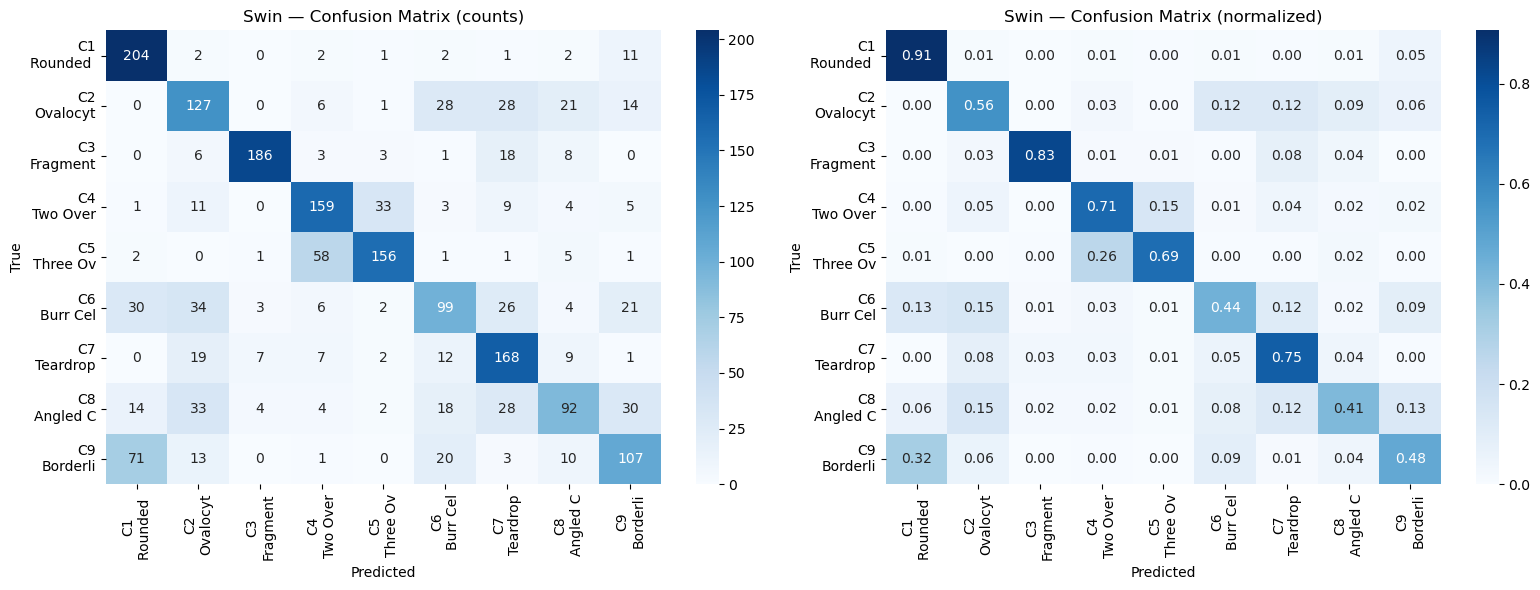

In [22]:
# ── Confusion Matrix Swin ──────────────────────────────────────────────────────
short_labels = [f"C{i+1}\n{CLASSES[i].split(' - ')[-1][:8]}" for i in range(len(CLASSES))]

cm = confusion_matrix(swin_labels, swin_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, data, title in [
    (axes[0], cm, "Swin — Confusion Matrix (counts)"),
    (axes[1], cm_norm, "Swin — Confusion Matrix (normalized)")
]:
    sns.heatmap(data, annot=True, fmt='.2f' if data.dtype == float else 'd',
                cmap='Blues', ax=ax,
                xticklabels=short_labels, yticklabels=short_labels)
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "swin_confusion_matrix.png"), dpi=150, bbox_inches='tight')
plt.show()

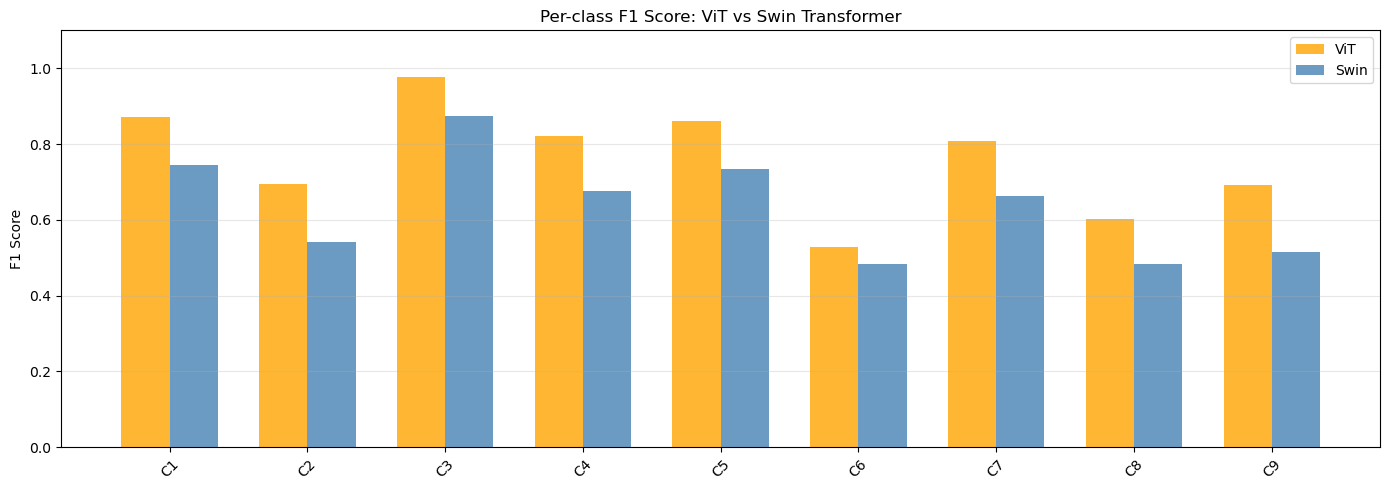


📋 Per-class F1:
Class                                 ViT F1  Swin F1   Winner
---------------------------------------------------------------
CROPPED - Class 1 - Rounded RBCs       0.871    0.746   ViT  🏆
CROPPED - Class 2 - Ovalocytes         0.695    0.540   ViT  🏆
CROPPED - Class 3 - Fragmented RB      0.976    0.873   ViT  🏆
CROPPED - Class 4 - Two Overlappi      0.820    0.675   ViT  🏆
CROPPED - Class 5 - Three Overlap      0.860    0.734   ViT  🏆
CROPPED - Class 6 - Burr Cells         0.527    0.484   ViT  🏆
CROPPED - Class 7 - Teardrops          0.807    0.663   ViT  🏆
CROPPED - Class 8 - Angled Cells       0.602    0.484   ViT  🏆
CROPPED - Class 9 - Borderline Ov      0.693    0.516   ViT  🏆

✅ Notebook hoàn tất! Weights lưu tại: c:\Users\DELL\Desktop\Vinh Hoang\Master Program\Học sâu\Project\results\classification\Swin_Cls_best.pt


In [23]:
# ── Per-class so sánh (nếu có cả 2 model) ─────────────────────────────────────
if vit_acc:
    from sklearn.metrics import f1_score
    swin_f1 = f1_score(swin_labels, swin_preds, average=None)
    vit_f1  = f1_score(vit_labels,  vit_preds,  average=None)

    x   = np.arange(len(CLASSES))
    w   = 0.35
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.bar(x - w/2, vit_f1,  w, label='ViT',  color='orange',   alpha=0.8)
    ax.bar(x + w/2, swin_f1, w, label='Swin', color='steelblue', alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels([f'C{i+1}' for i in range(len(CLASSES))], rotation=45)
    ax.set_ylabel('F1 Score')
    ax.set_title('Per-class F1 Score: ViT vs Swin Transformer')
    ax.legend()
    ax.set_ylim(0, 1.1)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, "swin_vs_vit_f1_perclass.png"), dpi=150, bbox_inches='tight')
    plt.show()

    print("\n📋 Per-class F1:")
    print(f"{'Class':<35} {'ViT F1':>8} {'Swin F1':>8} {'Winner':>8}")
    print("-"*63)
    for i, cls in enumerate(CLASSES):
        winner = "Swin 🏆" if swin_f1[i] > vit_f1[i] else "ViT  🏆"
        print(f"{cls[:33]:<35} {vit_f1[i]:>8.3f} {swin_f1[i]:>8.3f} {winner:>8}")

print("\n✅ Notebook hoàn tất! Weights lưu tại:", SWIN_PATH)

In [24]:
# ==============================================================================
# 🚀 PHẦN 2: SWIN TRANSFORMER CHO SEGMENTATION (Swin-UNet)
# ==============================================================================

# ── 1. Load Dataset Segmentation ──────────────────────────────────────────────
SLIDE_DIRS = [
    "Elsafty_RBCs_for_Segmentation_and_Detection_Slide_2",
    "Elsafty_RBCs_for_Segmentation_and_Detection_Slide_3"
]
MAX_SAMPLES_SEG = 5000

class RBCSegDataset(Dataset):
    def __init__(self, image_paths, mask_paths, img_size=80):
        self.image_paths = image_paths
        self.mask_paths  = mask_paths
        self.img_tf = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize([0.5]*3, [0.5]*3),
        ])
        self.mask_tf = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
        ])

    def __len__(self): return len(self.image_paths)

    def __getitem__(self, idx):
        img  = Image.open(self.image_paths[idx]).convert("RGB")
        mask = Image.open(self.mask_paths[idx]).convert("L")
        return self.img_tf(img), (self.mask_tf(mask) > 0.5).float()

def collect_seg_paths(base, slide_dirs, max_samples):
    imgs, masks = [], []
    for sd in slide_dirs:
        sd_path = Path(base) / sd
        img_files, mask_files = [], []
        
        for p in sd_path.rglob("*.*"):
            if not p.is_file() or p.name.startswith("."): continue
            if p.suffix.lower() not in {".png", ".jpg", ".jpeg", ".bmp"}: continue
            
            path_str = str(p.parent).lower()
            if "mask" in path_str or "label" in path_str:
                mask_files.append(p)
            elif "crop" in path_str or "image" in path_str:
                img_files.append(p)

        mask_dict = {m.stem: str(m) for m in mask_files}
        for img_p in img_files:
            stem = img_p.stem
            if stem in mask_dict:
                imgs.append(str(img_p))
                masks.append(mask_dict[stem])
                
    if len(imgs) == 0:
        return [], []
        
    idx = random.sample(range(len(imgs)), min(max_samples, len(imgs)))
    return [imgs[i] for i in idx], [masks[i] for i in idx]

img_paths_seg, mask_paths_seg = collect_seg_paths(DATASET_BASE, SLIDE_DIRS, MAX_SAMPLES_SEG)
print(f"Total Segmentation samples: {len(img_paths_seg)}")

if len(img_paths_seg) > 0:
    dataset_seg = RBCSegDataset(img_paths_seg, mask_paths_seg, IMG_SIZE)
    n_tr_seg = int(0.7 * len(dataset_seg))
    n_va_seg = int(0.15 * len(dataset_seg))
    n_te_seg = len(dataset_seg) - n_tr_seg - n_va_seg
    
    train_ds_s, val_ds_s, test_ds_s = torch.utils.data.random_split(
        dataset_seg, [n_tr_seg, n_va_seg, n_te_seg], 
        generator=torch.Generator().manual_seed(42)
    )
    
    seg_train_dl = DataLoader(train_ds_s, BATCH_SIZE, shuffle=True)
    seg_val_dl   = DataLoader(val_ds_s, BATCH_SIZE, shuffle=False)
    seg_test_dl  = DataLoader(test_ds_s, BATCH_SIZE, shuffle=False)
    print(f"Seg Train/Val/Test: {n_tr_seg}/{n_va_seg}/{n_te_seg}")
else:
    print("⚠ Lỗi: Không tìm thấy ảnh Mask/Crop nào!")


Total Segmentation samples: 5000
Seg Train/Val/Test: 3500/750/750


In [25]:
# ── 2. Swin-UNet Architecture ─────────────────────────────────────────────────
class PatchEmbedSeg(nn.Module):
    def __init__(self, img_size=80, patch_size=4, in_ch=3, embed_dim=64):
        super().__init__()
        self.proj = nn.Conv2d(in_ch, embed_dim, patch_size, patch_size)
    def forward(self, x):
        x = self.proj(x)
        B, E, H, W = x.shape
        return x.flatten(2).transpose(1, 2), H, W

class SwinUNet(nn.Module):
    def __init__(self, img_size=80, patch_size=4, in_ch=3, out_ch=1,
                 embed_dim=64, depth=2, heads=4, window_size=5):
        super().__init__()
        self.patch = PatchEmbedSeg(img_size, patch_size, in_ch, embed_dim)
        res = img_size // patch_size  # = 20
        
        # Swin ENCODER
        self.blocks = nn.ModuleList([
            SwinBlock(dim=embed_dim, num_heads=heads, window_size=window_size,
                      shift=(j % 2 == 1), input_resolution=(res, res)) 
            for j in range(depth)
        ])
        self.norm = nn.LayerNorm(embed_dim)
        
        # Simple CNN DECODER (Nhân 4 lần kích thước lên lại 80x80)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(embed_dim, 32, kernel_size=2, stride=2), # 20x20 -> 40x40
            nn.ReLU(), nn.BatchNorm2d(32),
            nn.ConvTranspose2d(32, 16, kernel_size=2, stride=2),        # 40x40 -> 80x80
            nn.ReLU(), nn.BatchNorm2d(16),
            nn.Conv2d(16, out_ch, kernel_size=1)                        # Trả về 1 channel (Mặt nạ nhị phân)
        )

    def forward(self, x):
        tokens, H, W = self.patch(x)
        for blk in self.blocks:
            tokens = blk(tokens)
        tokens = self.norm(tokens)
        
        B, N, E = tokens.shape
        spatial = tokens.transpose(1, 2).reshape(B, E, H, W)
        return self.decoder(spatial)

model_swin_seg = SwinUNet().to(DEVICE)
print(f"Swin-UNet params: {sum(p.numel() for p in model_swin_seg.parameters()):,}")


Swin-UNet params: 114,281


In [26]:
# ── 3. Loss & Training cho Segmentation ───────────────────────────────────────
def bce_dice_loss(pred, target):
    bce = F.binary_cross_entropy_with_logits(pred, target)
    pred_sig = torch.sigmoid(pred)
    num = 2 * (pred_sig * target).sum(dim=(1,2,3))
    den = pred_sig.sum(dim=(1,2,3)) + target.sum(dim=(1,2,3)) + 1e-6
    dice = (1 - num/den).mean()
    return bce + dice

def dice_score_eval(pred, target):
    pred_bin = (torch.sigmoid(pred) > 0.5).float()
    return (2*(pred_bin*target).sum() / (pred_bin.sum() + target.sum() + 1e-6)).item()

def train_seg_model(model, train_dl, val_dl, epochs=50, lr=1e-3):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    
    best_dice, no_improve = 0.0, 0
    seg_save_path = os.path.join(RESULTS_DIR, "Swin_Seg_best.pt")
    
    # 🆕 Lưu vào bộ nhớ để vẽ biểu đồ
    history = {'loss': [], 'dice': []}
    
    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0
        for imgs, masks in tqdm(train_dl, desc=f"Seg", leave=False):
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            optimizer.zero_grad()
            loss = bce_dice_loss(model(imgs), masks)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            
        model.eval()
        val_dice_sum = 0
        with torch.no_grad():
            for imgs, masks in val_dl:
                imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
                val_dice_sum += dice_score_eval(model(imgs), masks)
                
        avg_loss = total_loss/len(train_dl)
        avg_dice = val_dice_sum / len(val_dl)
        history['loss'].append(avg_loss)
        history['dice'].append(avg_dice)
        
        scheduler.step()
        print(f"Epoch {epoch:02d}/{epochs} | Loss: {avg_loss:.4f} | Val Dice: {avg_dice:.4f}")
        
        if avg_dice > best_dice:
            best_dice = avg_dice
            torch.save(model.state_dict(), seg_save_path)
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= 8:
                print("🛑 Early stopping Segmentation!")
                break
                
    print(f"\n✅ Training Segmentation xong! Best Dice = {best_dice:.4f}")
    return history

seg_history = train_seg_model(model_swin_seg, seg_train_dl, seg_val_dl, )


Epoch 01/50 | Loss: 1.3320 | Val Dice: 0.5200


Epoch 02/50 | Loss: 1.1326 | Val Dice: 0.5510


Epoch 03/50 | Loss: 0.9303 | Val Dice: 0.6137


Epoch 04/50 | Loss: 0.7566 | Val Dice: 0.6802


Epoch 05/50 | Loss: 0.6541 | Val Dice: 0.6950


...

Epoch 46/50 | Loss: 0.2708 | Val Dice: 0.8417


Epoch 47/50 | Loss: 0.2726 | Val Dice: 0.8417


Epoch 48/50 | Loss: 0.2709 | Val Dice: 0.8417


Epoch 49/50 | Loss: 0.2717 | Val Dice: 0.8418


Epoch 50/50 | Loss: 0.2701 | Val Dice: 0.8419

✅ Training Segmentation xong! Best Dice = 0.8419


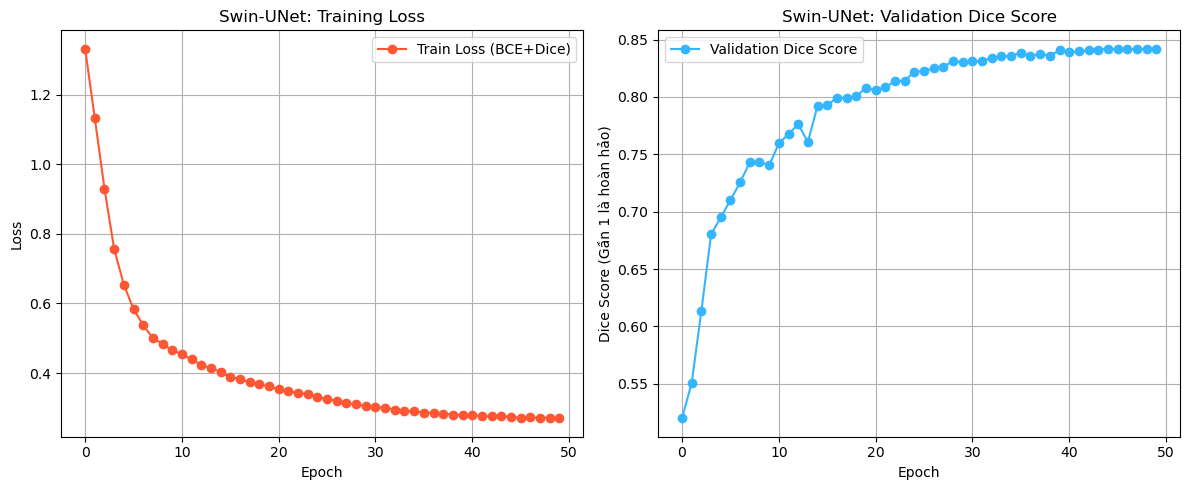

In [27]:
# ── 4. Vẽ biểu đồ quá trình học (Learning Curves) ─────────────────────────────
if 'seg_history' in locals() and seg_history is not None:
    plt.figure(figsize=(12, 5))
    
    # Biểu đồ Loss
    plt.subplot(1, 2, 1)
    plt.plot(seg_history['loss'], label='Train Loss (BCE+Dice)', color='#FF5733', marker='o')
    plt.title('Swin-UNet: Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True)
    plt.legend()
    
    # Biểu đồ Dice Score
    plt.subplot(1, 2, 2)
    plt.plot(seg_history['dice'], label='Validation Dice Score', color='#33B5FF', marker='o')
    plt.title('Swin-UNet: Validation Dice Score')
    plt.xlabel('Epoch')
    plt.ylabel('Dice Score (Gần 1 là hoàn hảo)')
    plt.grid(True)
    plt.legend()
    
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, "swin_seg_curves.png"), dpi=150)
    plt.show()
else:
    print("⚠ Chưa có history để vẽ biểu đồ. Nhớ bỏ hashtag ở cell 3 và chạy train_seg_model trước!")


🎯 Điểm Dice Score trên tập TEST: 0.8319



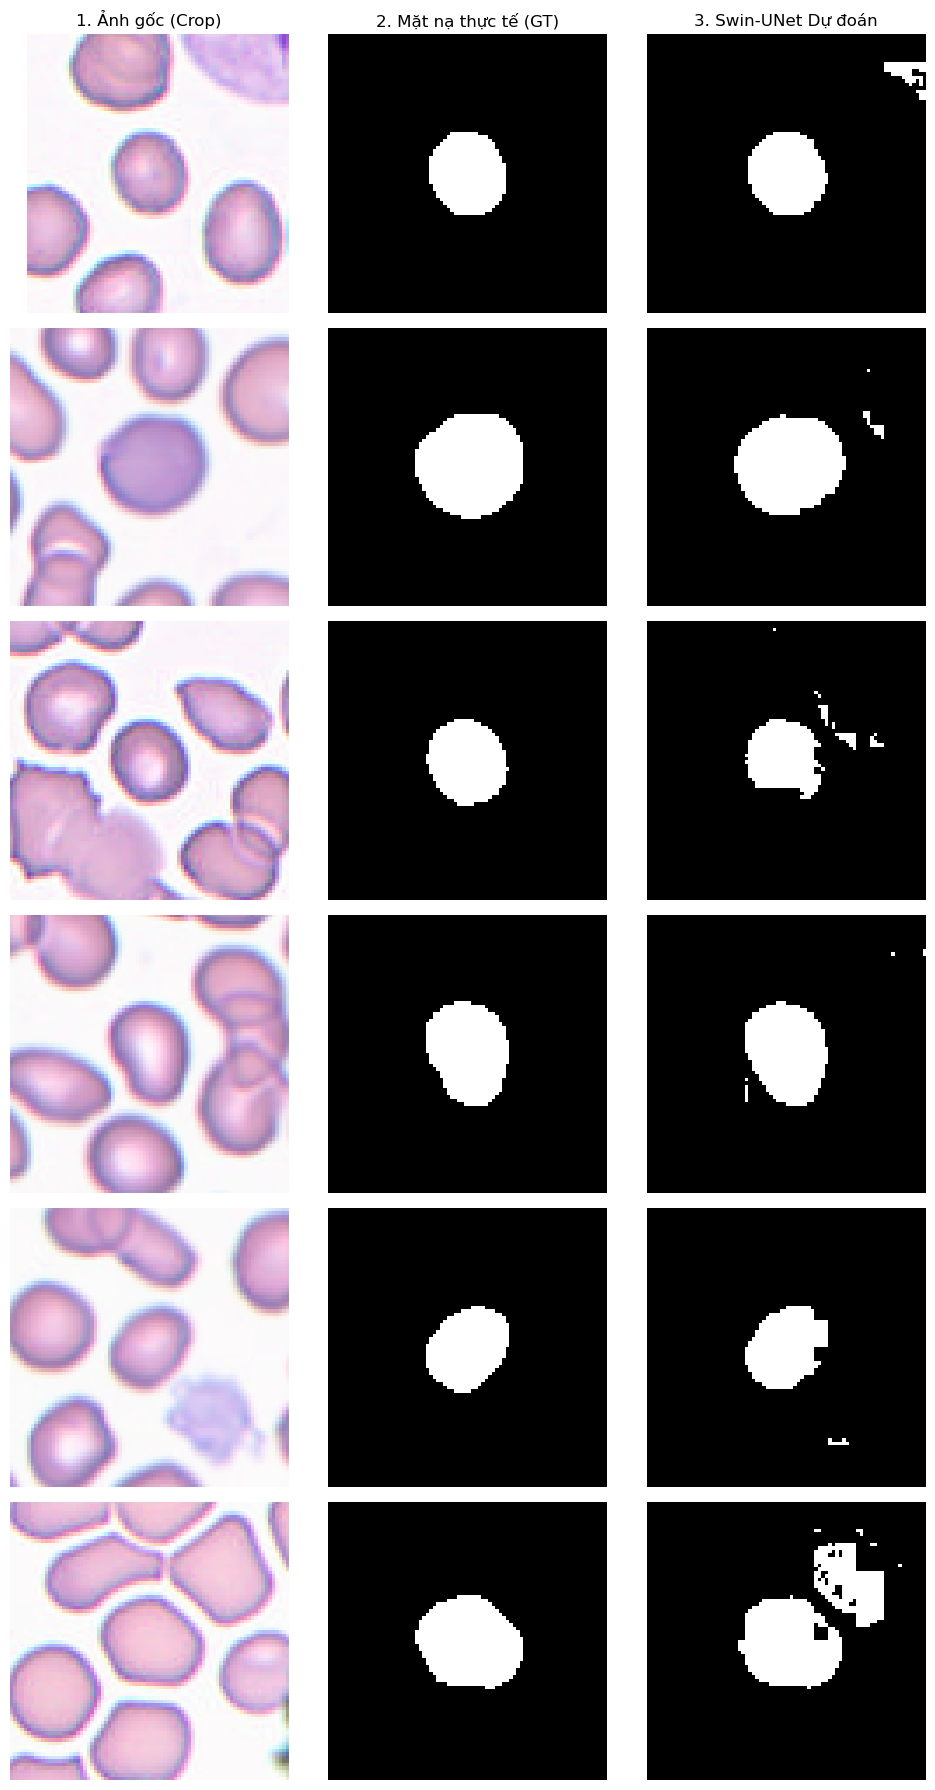

In [28]:
# ── 5. Đánh giá trên tập Test & Visualize (So sánh mắt thường) ────────────────
best_path = os.path.join(RESULTS_DIR, "Swin_Seg_best.pt")
if os.path.exists(best_path):
    model_swin_seg.load_state_dict(torch.load(best_path, map_location=DEVICE))
model_swin_seg.eval()

# Đo điểm Dice Score trung bình trên tập Test riêng rẽ
test_dice_sum = 0
with torch.no_grad():
    for imgs, masks in seg_test_dl:
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        test_dice_sum += dice_score_eval(model_swin_seg(imgs), masks)
print(f"🎯 Điểm Dice Score trên tập TEST: {test_dice_sum/len(seg_test_dl):.4f}\n")

# ---- VẼ ẢNH HIỂN THỊ ----
sample_imgs, sample_masks = next(iter(seg_test_dl))
sample_imgs = sample_imgs.to(DEVICE)

with torch.no_grad():
    preds = model_swin_seg(sample_imgs)
    preds_bin = (torch.sigmoid(preds) > 0.5).float() # Ngưỡng 0.5 để quyết định pixel là Hồng Cầu hay Nền

sample_imgs = sample_imgs.cpu().numpy()
sample_masks = sample_masks.cpu().numpy()
preds_bin = preds_bin.cpu().numpy()

num_show = min(6, sample_imgs.shape[0]) 
fig, axes = plt.subplots(num_show, 3, figsize=(10, 3 * num_show))

for i in range(num_show):
    # Khôi phục màu sắc ban đầu của ảnh Crop
    img = sample_imgs[i]
    img = np.transpose(img, (1, 2, 0)) # Chuyển CHW -> HWC
    img = img * 0.5 + 0.5              # Hàng Normalize trước đó
    img = np.clip(img, 0, 1)
    
    gt_mask = sample_masks[i][0]       # Mặt nạ bác sĩ đánh dấu (Thực tế)
    pred_mask = preds_bin[i][0]        # Mặt nạ AI vẽ 
    
    axes[i, 0].imshow(img)
    axes[i, 0].set_title("1. Ảnh gốc (Crop)" if i==0 else "")
    axes[i, 0].axis("off")
    
    axes[i, 1].imshow(gt_mask, cmap='gray')
    axes[i, 1].set_title("2. Mặt nạ thực tế (GT)" if i==0 else "")
    axes[i, 1].axis("off")
    
    axes[i, 2].imshow(pred_mask, cmap='gray')
    axes[i, 2].set_title("3. Swin-UNet Dự đoán" if i==0 else "")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "swin_seg_visualize.png"), dpi=150)
plt.show()
